In [103]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder , StandardScaler 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split , GridSearchCV , validation_curve
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score , roc_auc_score
from sklearn.linear_model import LinearRegression , Ridge , Lasso



In [104]:
df = pd.read_csv(r"C:\Users\Ameen\Desktop\MyProjects-P\New York City Airbnb\archive\AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [105]:
print(df.info())

print("-" * 80)

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

EDA :

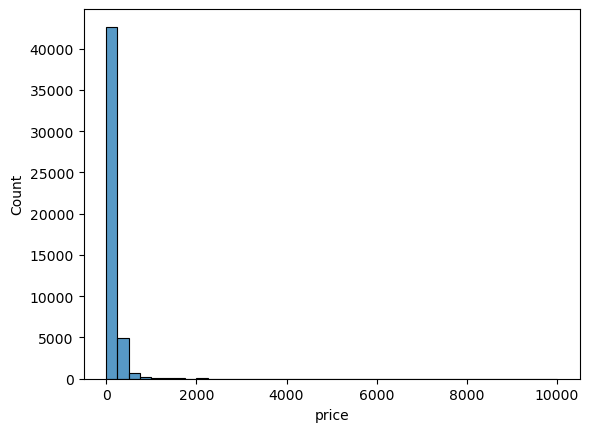

In [106]:
sns.histplot(df["price"] , bins=40)
plt.show()

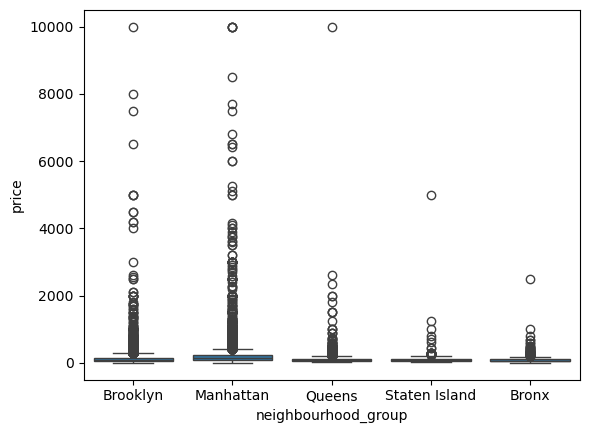

In [107]:
sns.boxplot(x="neighbourhood_group" , y="price" , data=df)
plt.show()

<Axes: xlabel='room_type', ylabel='price'>

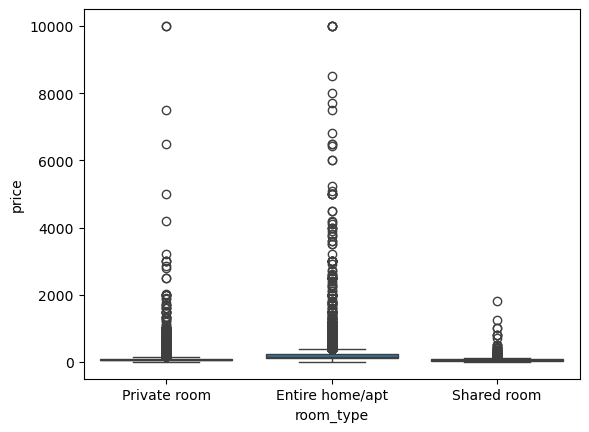

In [108]:
sns.boxplot(x="room_type" , y="price" , data=df)

<Axes: xlabel='number_of_reviews', ylabel='price'>

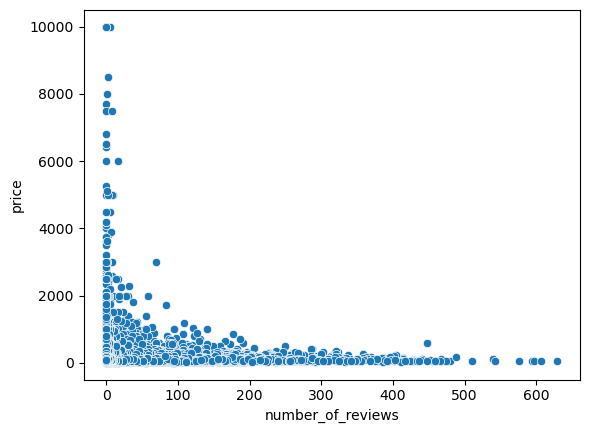

In [109]:
sns.scatterplot(x="number_of_reviews" , y="price" , data=df)

<Axes: xlabel='minimum_nights', ylabel='price'>

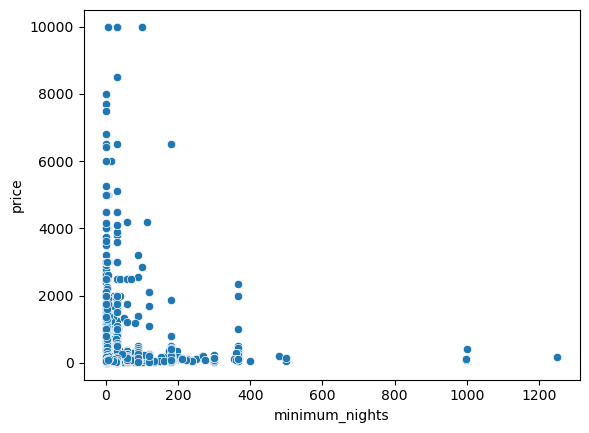

In [110]:
sns.scatterplot(x="minimum_nights" , y="price" , data=df)

<Axes: >

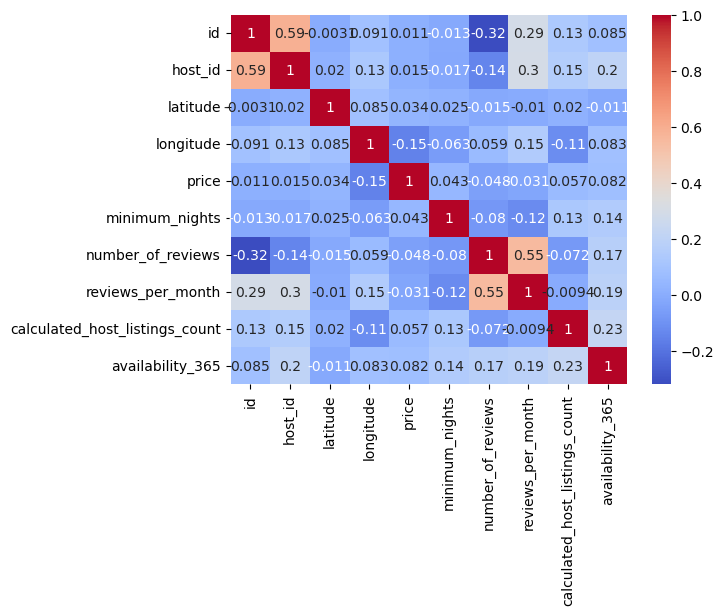

In [111]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr , annot=True , cmap="coolwarm")

Data Cleaning :

In [112]:
df["price"].quantile([0.90 , 0.95 , 0.99])

0.90    269.0
0.95    355.0
0.99    799.0
Name: price, dtype: float64

In [113]:
df["price"] = np.where(df["price"] > 1000 , 1000 , df["price"])
df["price"].describe()

count    48895.000000
mean       145.477288
std        130.950025
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max       1000.000000
Name: price, dtype: float64

In [114]:
df["price"] = np.log1p(df["price"])
df["price"].describe()

count    48895.000000
mean         4.733364
std          0.681265
min          0.000000
25%          4.248495
50%          4.672829
75%          5.170484
max          6.908755
Name: price, dtype: float64

In [115]:
del df["name"]
del df["host_id"]
del df["host_name"]

In [116]:
df.isnull().sum()

id                                    0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [117]:
df.fillna(0 , inplace = True)
df.isnull().sum()

id                                0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Feature Engineering :

In [118]:
df["neighbourhood_density"] = df.groupby("neighbourhood")["id"].transform("count")

df["multi_host"] = (df["calculated_host_listings_count"] > 3).astype(int)

df["review_score"] = df["number_of_reviews"] * df["reviews_per_month"]

df["demand_ratio"] = df["number_of_reviews"] / (df["availability_365"] + 1)

df["reviews_per_year"] = df["reviews_per_month"] * 12

df["distance_center"] = (
    (df["latitude"] - 40.7128) **2 + (df["longitude"] + 74.0060) **2
      ) **0.5

Preprocessing :

In [119]:
num_features = [
    "minimum_nights" ,
    "number_of_reviews" ,
    "reviews_per_month" ,
    "availability_365" ,
    "calculated_host_listings_count" ,
    "latitude" ,
    "longitude"
]

cat_features = [
    "neighbourhood_group" ,
    "room_type"
]

In [120]:
x = df.drop("price" , axis=1)
y = df["price"]

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

preprocerssor = ColumnTransformer(
    transformers=[
        ("cat" , OneHotEncoder(handle_unknown="ignore" , drop="first") , cat_features) ,
        ("num" , StandardScaler() , num_features) 
    ]
)

models preparation :

In [123]:
all_reg_models_results = []

In [121]:
def evaluate_regression_model(model, X_test, y_test, model_name="Model"):
    # 1. التوقعات
    y_pred = model.predict(X_test)
    
    # 2. حساب المقاييس (Metrics)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # أو يمكن استخدام mean_squared_error(..., squared=False)
    r2 = r2_score(y_test, y_pred)
    
    # 3. إرجاع النتائج كـ Dictionary
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,      # اختياري، بس مفيد للمقارنة
        "R2_Score": r2
    }

In [122]:
def val_curves(model , x_train , y_train , param_name , cv , param_range):

    train_scores, test_scores = validation_curve(
        model , 
        x_train , 
        y_train , 
        param_name = param_name , 
        param_range = param_range ,
        cv = cv , 
        scoring = "neg_root_mean_squared_error" , 
        n_jobs = -1
    )

    train_mean = abs(np.mean(train_scores , axis=1))
    train_std = np.std(train_scores , axis=1)
    test_mean = abs(np.mean(test_scores , axis=1))
    test_std = np.std(test_scores , axis=1)

    plt.figure(figsize = (10, 6))
    plt.title("Validation Curve")
    plt.xlabel("param (Complexity)")
    plt.ylabel("RMSE Error (Lower is Better)")

    plt.plot(param_range, train_mean , label = "Training Error" , color = "darkorange", lw = 2 , marker = 'o')
    plt.fill_between(param_range, train_mean - train_std , train_mean + train_std , alpha = 0.1 , color = "darkorange")

    # رسم منطقة التيست
    plt.plot(param_range , test_mean , label = "Validation Error" , color = "navy" , lw = 2, marker = 'o')
    plt.fill_between(param_range , test_mean - test_std , test_mean + test_std , alpha = 0.1 , color = "navy")

    plt.legend(loc = "best")
    plt.grid()
    plt.show()